# Applying the Score-Driven and SMC filters specified for our robust dynamical model.

## Setup


In [2]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('script.py')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from dataclasses import replace
from IPython.display import display

import robust_ssm as ss


plt.rcParams.update({
    'figure.dpi':          120,
    'font.size':           11,
    'axes.titlesize':      11,
    'axes.labelsize':      11,
    'legend.fontsize':     9,
    'legend.framealpha':   0.85,
    'legend.edgecolor':    '#CCCCCC',
    'axes.grid':           True,
    'grid.alpha':          0.35,
    'grid.linewidth':      0.5,
    'grid.color':          '#CCCCCC',
    'lines.linewidth':     1.6,
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.edgecolor':      '#555555',
    'xtick.color':         '#555555',
    'ytick.color':         '#555555',
})

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

SEED = 42
print('All modules loaded successfully.')
print(f'NumPy {np.__version__} | pandas {pd.__version__}')


All modules loaded successfully.
NumPy 2.4.3 | pandas 3.0.1


### Simulation Parameters


In [3]:
p_base = ss.ModelParams(nu=8.0, seed=SEED)

## The Sub-Gaussian Distribution

Compares three distributions with the **same scale $w = 1$** and $\nu_\eta = 8$:

- **Gaussian** $N(0, w^2)$: the standard benchmark
- **Student-$t$** $t(\nu_\eta, 0, w)$: heavy-tailed, used as the *base* for the transformation
- **Sub-Gaussian** (via score transform): bounded, lighter-than-Gaussian tails

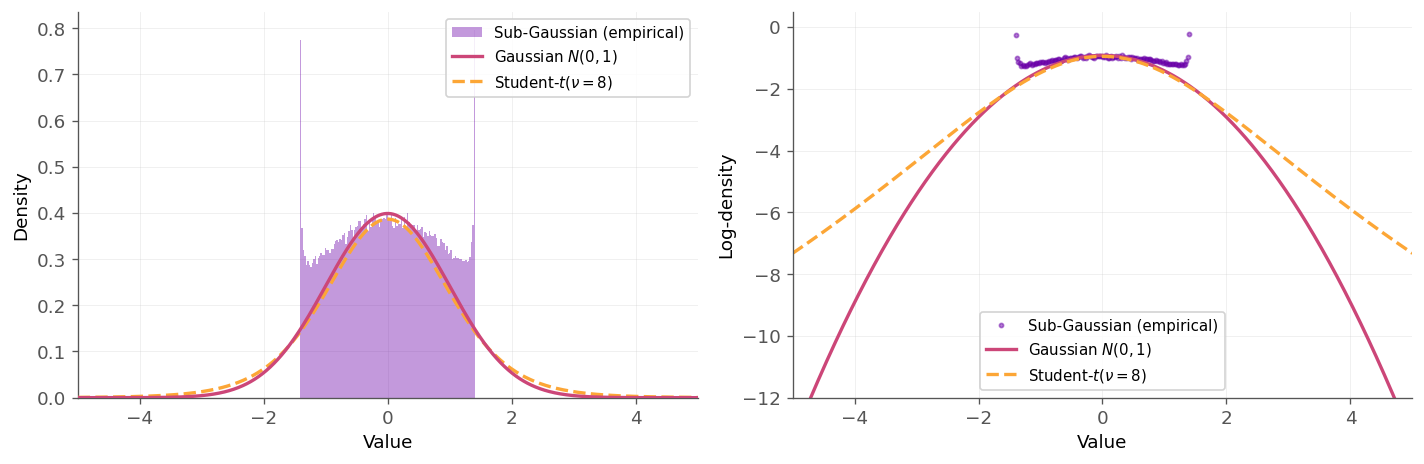

In [ ]:
rng_sg = np.random.default_rng(0)
nu_sg, w_sg = 8.0, 1.0
N_sg = 200_000

sg_samples = ss.sub_gaussian_rvs(N_sg, scale=w_sg, nu=nu_sg, rng=rng_sg)

x = np.linspace(-5, 5, 800)
t_pdf     = stats.t.pdf(x, df=nu_sg, scale=w_sg)
gauss_pdf = stats.norm.pdf(x, scale=w_sg)

C_SG    = "#6A00A8"
C_GAUSS = "#CC4678"
C_T     = "#FCA636"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(sg_samples, bins=120, density=True,
        color=C_SG, alpha=0.40, label='Sub-Gaussian (empirical)', zorder=2)
ax.plot(x, gauss_pdf, '-',  color=C_GAUSS, lw=2.0, label=r'Gaussian $N(0,1)$',       zorder=4)
ax.plot(x, t_pdf,     '--', color=C_T,     lw=2.0, label=r'Student-$t(\nu=8)$',      zorder=3)
ax.set_xlim(-5, 5)
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
sg_log_dens, bin_edges = np.histogram(sg_samples, bins=120, density=True)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
mask = sg_log_dens > 0
ax.plot(bin_centres[mask], np.log(sg_log_dens[mask]),
        'o', ms=2.5, color=C_SG, alpha=0.50, label='Sub-Gaussian (empirical)')
ax.plot(x, np.log(gauss_pdf), '-',  color=C_GAUSS, lw=2.0, label=r'Gaussian $N(0,1)$')
ax.plot(x, np.log(t_pdf),     '--', color=C_T,     lw=2.0, label=r'Student-$t(\nu=8)$')
ax.set_xlim(-5, 5)
ax.set_ylim(-12, 0.5)
ax.set_xlabel('Value')
ax.set_ylabel('Log-density')
ax.legend()

plt.tight_layout()
plt.savefig('figs/sub_gaussian_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Concavity Analysis & Score Function

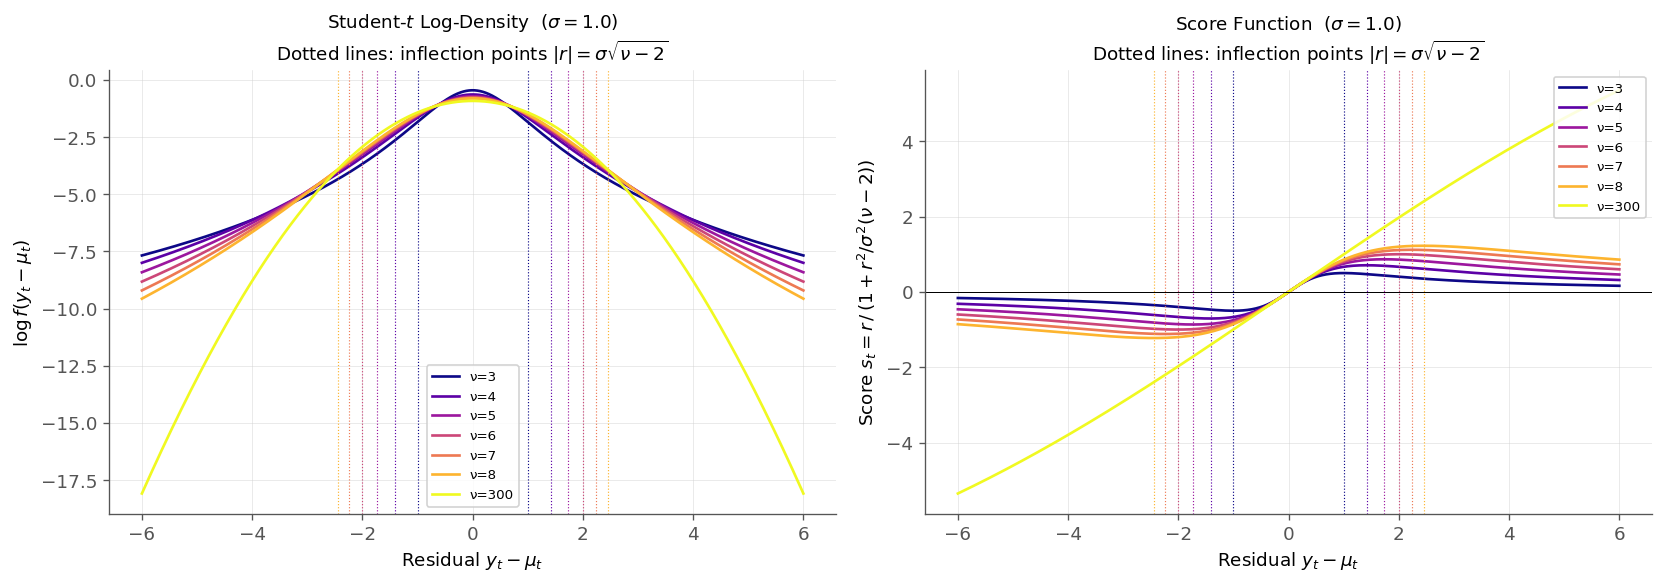

ν,Concavity radius √νσ,Score max value σ√ν/2
3,1.732,0.8660
4,2.000,1.0000
5,2.236,1.1180
6,2.449,1.2247
7,2.646,1.3229
8,2.828,1.4142
300,17.321,8.6603


In [ ]:
fig_conc = ss.plot_concavity(p_base, nu_list=[3, 4, 5, 6, 7, 8, 300])
fig_conc.savefig('figs/concavity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

#  inflection radii
nu_list = [3, 4, 5, 6, 7, 8, 300]
infl_df = pd.DataFrame({
    'ν':                    nu_list,
    'Concavity radius √νσ': [f'{np.sqrt(nu):.3f}' for nu in nu_list],
    'Score max value σ√ν/2':      [f'{np.sqrt(nu)*0.5:.4f}' for nu in nu_list],
})
display(
    infl_df.style
    .set_caption('Score Function Properties by Degrees of Freedom (σ=1)')
    .hide(axis='index')
    .set_properties(**{'text-align': 'center'})
)


## initial run: ($\nu = 8$)

In [ ]:
print('Single run with ν=8, T=300, N=1000...')
res = ss.run_experiment(p_base, verbose=False)
print(f"Done.  κ_ML = {res['kappa_ml']:.4f}")

sd_label = res['metrics_sd']['label']

metrics_df = pd.DataFrame([
    {
        'Filter':              m['label'],
        'RMSE':                m['RMSE'],
        'MAE':                 m['MAE'],
        'Bias':                m['Bias'],
        'Correlation':         m['Corr'],
        'Max |Error|':         m['MaxAE'],
    }
    for m in [res['metrics_smc'], res['metrics_sd']]
]).set_index('Filter')


display(
    metrics_df.style
    .set_caption(f'Filter Performance Metrics  (ν=8, T={p_base.T}, N={p_base.N})')
    .format({
        'RMSE':        '{:.4f}',
        'MAE':         '{:.4f}',
        'Bias':        '{:+.4f}',
        'Correlation': '{:.4f}',
        'Max |Error|': '{:.3f}',
    })
    .background_gradient(
        cmap='RdYlGn_r',
        subset=pd.IndexSlice[['SMC', sd_label], ['RMSE', 'MAE', 'Max |Error|']]
    )
    .background_gradient(
        cmap='RdYlGn',
        subset=pd.IndexSlice[['SMC', sd_label], ['Correlation']]
    )
)

Single run with ν=8, T=300, N=1000...
Done.  κ_ML = 0.5723


,RMSE,MAE,Bias,Correlation,Max |Error|
Filter,,,,,
SMC,0.7220,0.5728,-0.0328,0.7934,2.869
Score-driven (κ=0.572),0.7600,0.6049,-0.0109,0.7772,2.972


### Filter Trajectories

 The shaded band is the SMC 90% credible interval $\hat{\mu}_t \pm 1.645\sqrt{\widehat{\text{Var}}_t}$.


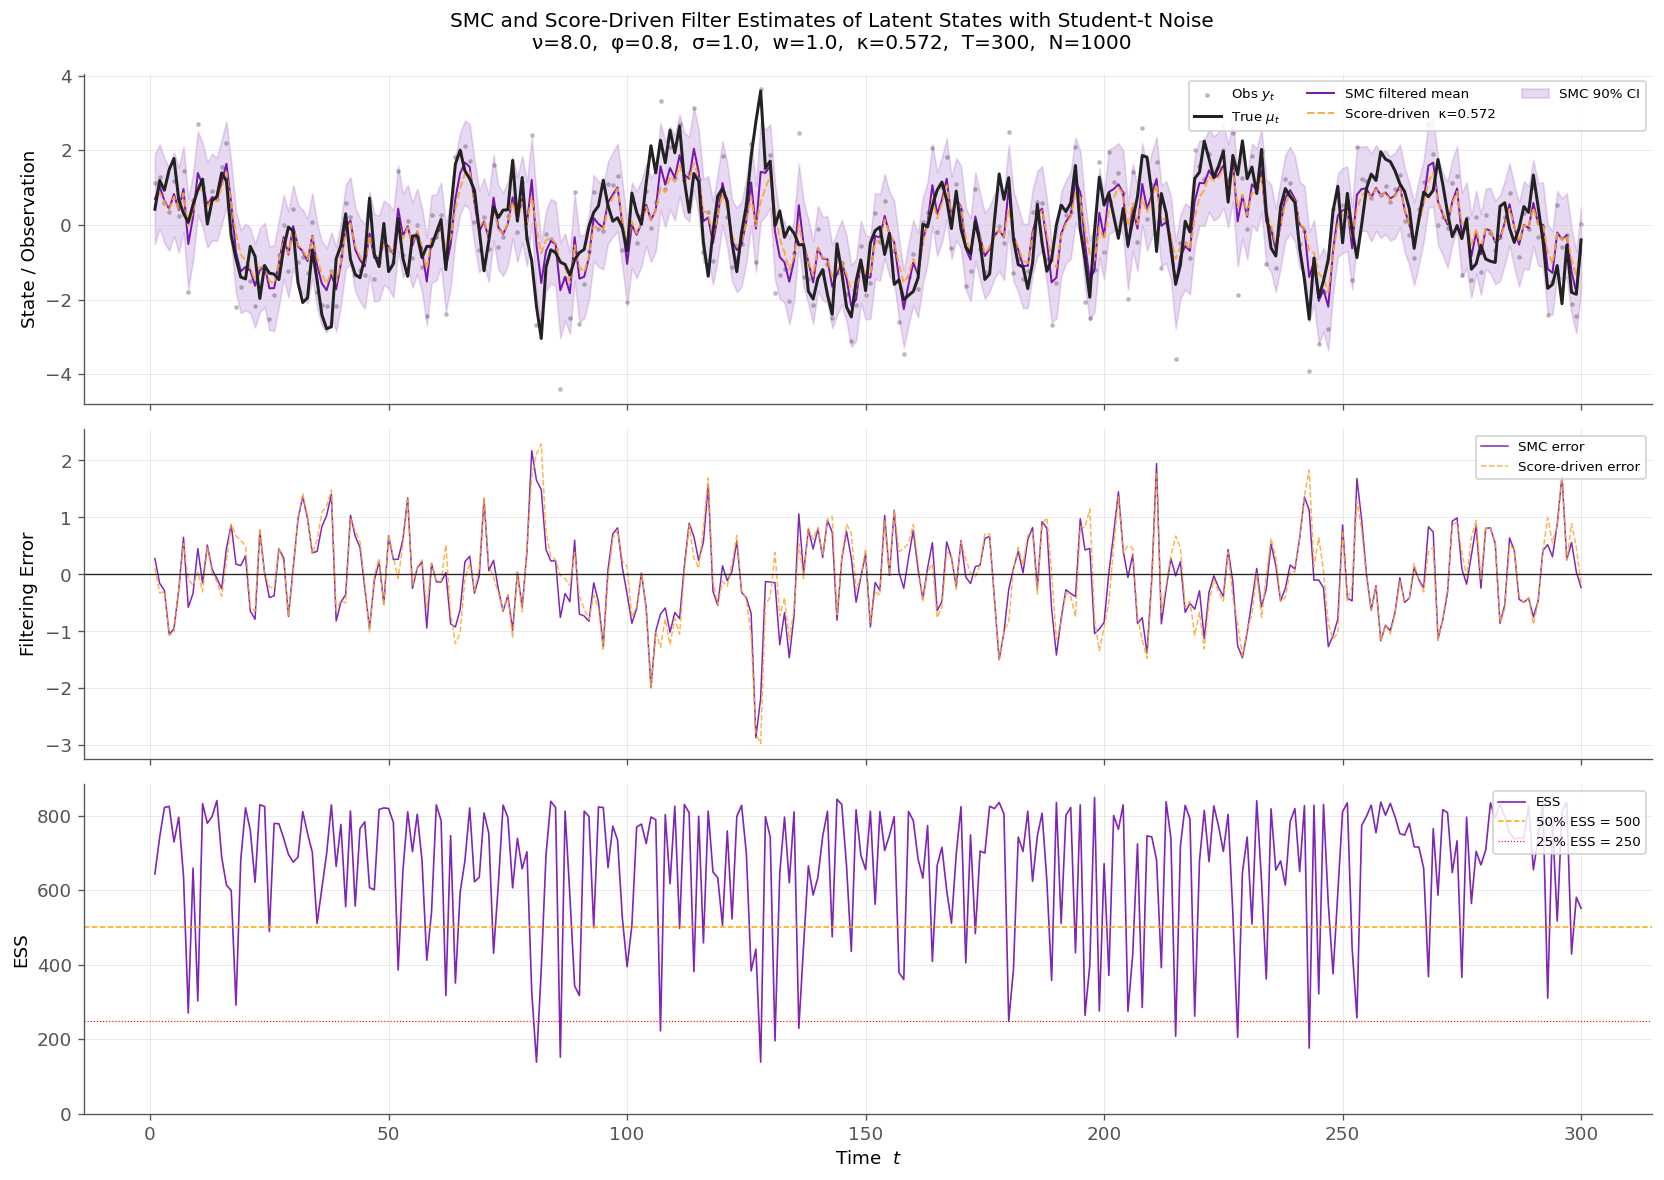

In [7]:
fig = ss.plot_paths(res)
plt.savefig('figs/filter_paths.png', dpi=150, bbox_inches='tight')
plt.show()


### Rolling RMSE

The score-driven filter's redescending score should limit the impact of individual outliers, but the SMC retains particle diversity that may adapt faster.


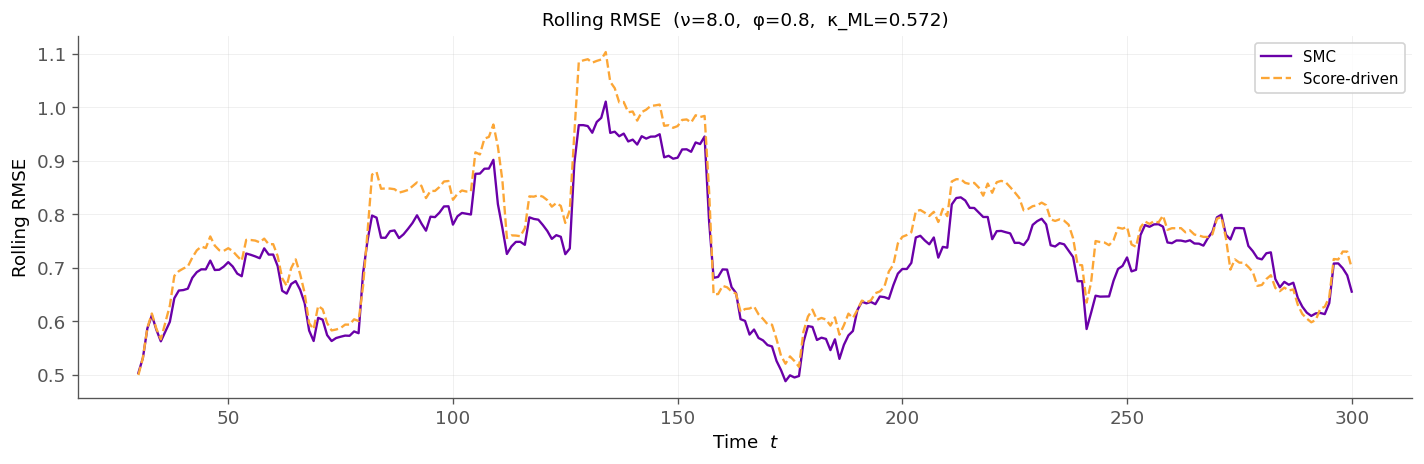

In [8]:
fig = ss.plot_rolling_rmse(res, window=30)
plt.savefig('figs/rolling_rmse.png', dpi=150, bbox_inches='tight')
plt.show()


## Sensitivity to Degrees of Freedom

We repeat the experiment for $\nu \in \{3, 4, 5, 6, 7, 8, 9, 30, 100, 300, 400, 500, 600, 700\}$ holding all other parameters fixed. As $\nu$ decreases, observing outliers becomes more likely due to heavier tails


In [10]:
nu_sweep_vals = [3, 4, 5, 6, 7, 8, 9, 30, 100, 300, 400, 500, 600, 700]
sweep_results = {}

for nu_val in nu_sweep_vals:
    print(f'Running ν={nu_val}...')
    p = ss.ModelParams(nu=float(nu_val), seed=SEED)
    sweep_results[nu_val] = ss.run_experiment(p, verbose=False)


Running ν=3...
Running ν=4...
Running ν=5...
Running ν=6...
Running ν=7...
Running ν=8...
Running ν=9...
Running ν=30...
Running ν=100...
Running ν=300...
Running ν=400...
Running ν=500...
Running ν=600...
Running ν=700...


In [11]:
# comparison table
records = []
for nu_val in nu_sweep_vals:
    r = sweep_results[nu_val]
    smc = r['metrics_smc']
    sd  = r['metrics_sd']
    kf  = r['metrics_kf']
    kappa = r['kappa_ml']
    smc_sd_corr = np.corrcoef(r['mu_smc'], r['mu_sd'])[0, 1]
    records.append({
        'ν':              nu_val,
        'κ':              round(kappa, 3),
        'KF RMSE':        kf['RMSE'],
        'SMC RMSE':       smc['RMSE'],
        'SD RMSE':        sd['RMSE'],
        'SMC / KF':       smc['RMSE'] / kf['RMSE'],
        'SD / SMC':       sd['RMSE']  / smc['RMSE'],
        'SMC MAE':        smc['MAE'],
        'SD MAE':         sd['MAE'],
        'SMC Corr':       smc['Corr'],
        'SD Corr':        sd['Corr'],
        'SMC Bias':       smc['Bias'],
        'SD Bias':        sd['Bias'],
        'Corr(SMC,SD)':   smc_sd_corr,
    })

sweep_df = pd.DataFrame(records).set_index('ν')

display(
    sweep_df.style
    .set_caption('Filter Performance vs Degrees of Freedom  (T=300, N=1000)')
    .format({
        'κ':            '{:.3f}',
        'KF RMSE':      '{:.4f}',
        'SMC RMSE':     '{:.4f}',
        'SD RMSE':      '{:.4f}',
        'SMC / KF':     '{:.3f}×',
        'SD / SMC':     '{:.3f}×',
        'SMC MAE':      '{:.4f}',
        'SD MAE':       '{:.4f}',
        'SMC Corr':     '{:.4f}',
        'SD Corr':      '{:.4f}',
        'SMC Bias':     '{:+.4f}',
        'SD Bias':      '{:+.4f}',
        'Corr(SMC,SD)': '{:.4f}',
    })
    .background_gradient(cmap='RdYlGn_r', subset=['KF RMSE', 'SMC RMSE', 'SD RMSE'])
    .background_gradient(cmap='RdYlGn_r', subset=['SMC / KF', 'SD / SMC'])
    .background_gradient(cmap='RdYlGn',   subset=['SMC Corr', 'SD Corr', 'Corr(SMC,SD)'])
    .set_properties(**{'text-align': 'center'})
)

,κ,KF RMSE,SMC RMSE,SD RMSE,SMC / KF,SD / SMC,SMC MAE,SD MAE,SMC Corr,SD Corr,SMC Bias,SD Bias,"Corr(SMC,SD)"
ν,,,,,,,,,,,,,
3,0.811,0.6757,0.5261,0.5867,0.779×,1.115×,0.3991,0.4818,0.8100,0.7759,+0.0489,+0.0387,0.9341
4,0.774,0.7227,0.5947,0.6309,0.823×,1.061×,0.4556,0.4975,0.7998,0.7770,+0.0132,+0.0234,0.9644
5,0.720,0.7240,0.6439,0.6645,0.889×,1.032×,0.4932,0.5216,0.7958,0.7869,+0.0009,+0.0199,0.9747
6,0.705,0.7241,0.6731,0.6703,0.930×,0.996×,0.5123,0.5201,0.8044,0.8122,-0.0016,+0.0183,0.9817
7,0.731,0.7233,0.6851,0.6801,0.947×,0.993×,0.5302,0.5250,0.8127,0.8184,-0.0236,+0.0045,0.9871
8,0.572,0.7325,0.7220,0.7600,0.986×,1.053×,0.5728,0.6049,0.7934,0.7772,-0.0328,-0.0109,0.9802
9,0.546,0.7153,0.7019,0.7447,0.981×,1.061×,0.5619,0.5997,0.8156,0.8031,-0.0407,-0.0284,0.9825
30,0.487,0.7607,0.7554,0.7952,0.993×,1.053×,0.6061,0.6324,0.8342,0.8277,-0.0122,+0.0024,0.9869
100,0.473,0.7582,0.7576,0.7730,0.999×,1.020×,0.6112,0.6230,0.8451,0.8454,-0.0333,-0.0285,0.9944


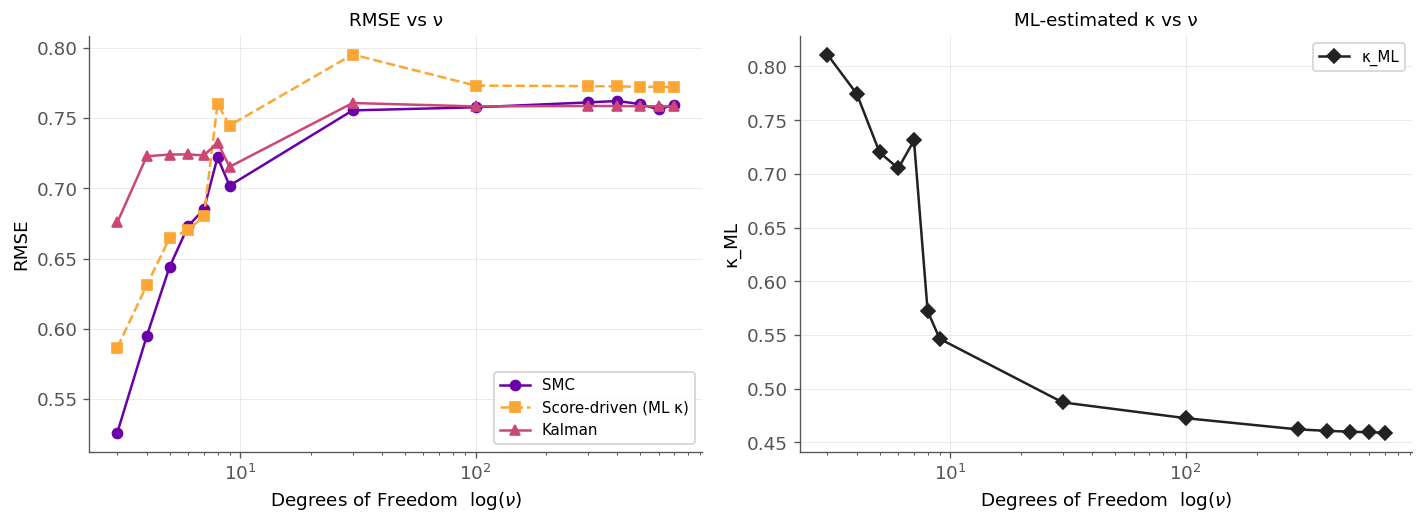

In [12]:
fig = ss.plot_dof_sweep(sweep_results)
plt.savefig('figs/dof_sweep_single.png', dpi=150, bbox_inches='tight')
plt.show()

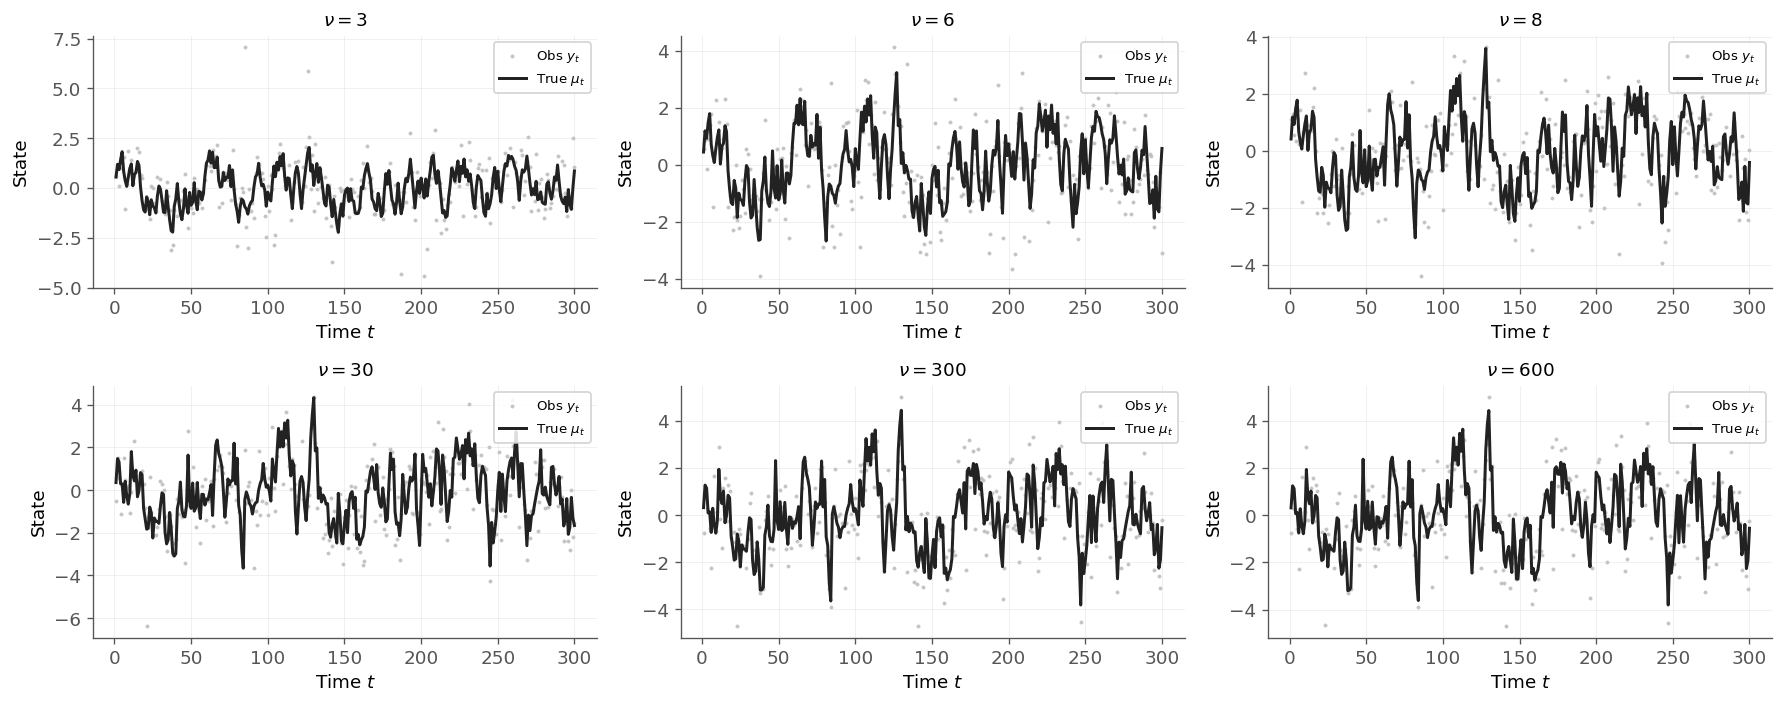

In [ ]:
# true state paths for a selection of ν values (model specification figure)
nu_showcase = [3, 6, 8, 30, 300, 600]
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey=False)
axes_flat = axes.flatten()

for ax, nu_val in zip(axes_flat, nu_showcase):
    r  = sweep_results[nu_val]
    t  = np.arange(1, r['params'].T + 1)
    mu = r['mu']

    ax.scatter(t, r['y'],  s=2, c='#B8B8B8', zorder=1, alpha=0.7, label=r'Obs $y_t$')
    ax.plot(t, mu[1:], '-', color='#222222', lw=1.8, zorder=4, label=r'True $\mu_t$')
    ax.set_title(r'$\nu=' + str(nu_val) + r'$', fontweight='bold')
    ax.set_ylabel('State')
    ax.set_xlabel('Time $t$')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('figs/model_paths_grid.png', dpi=150, bbox_inches='tight')
plt.show()

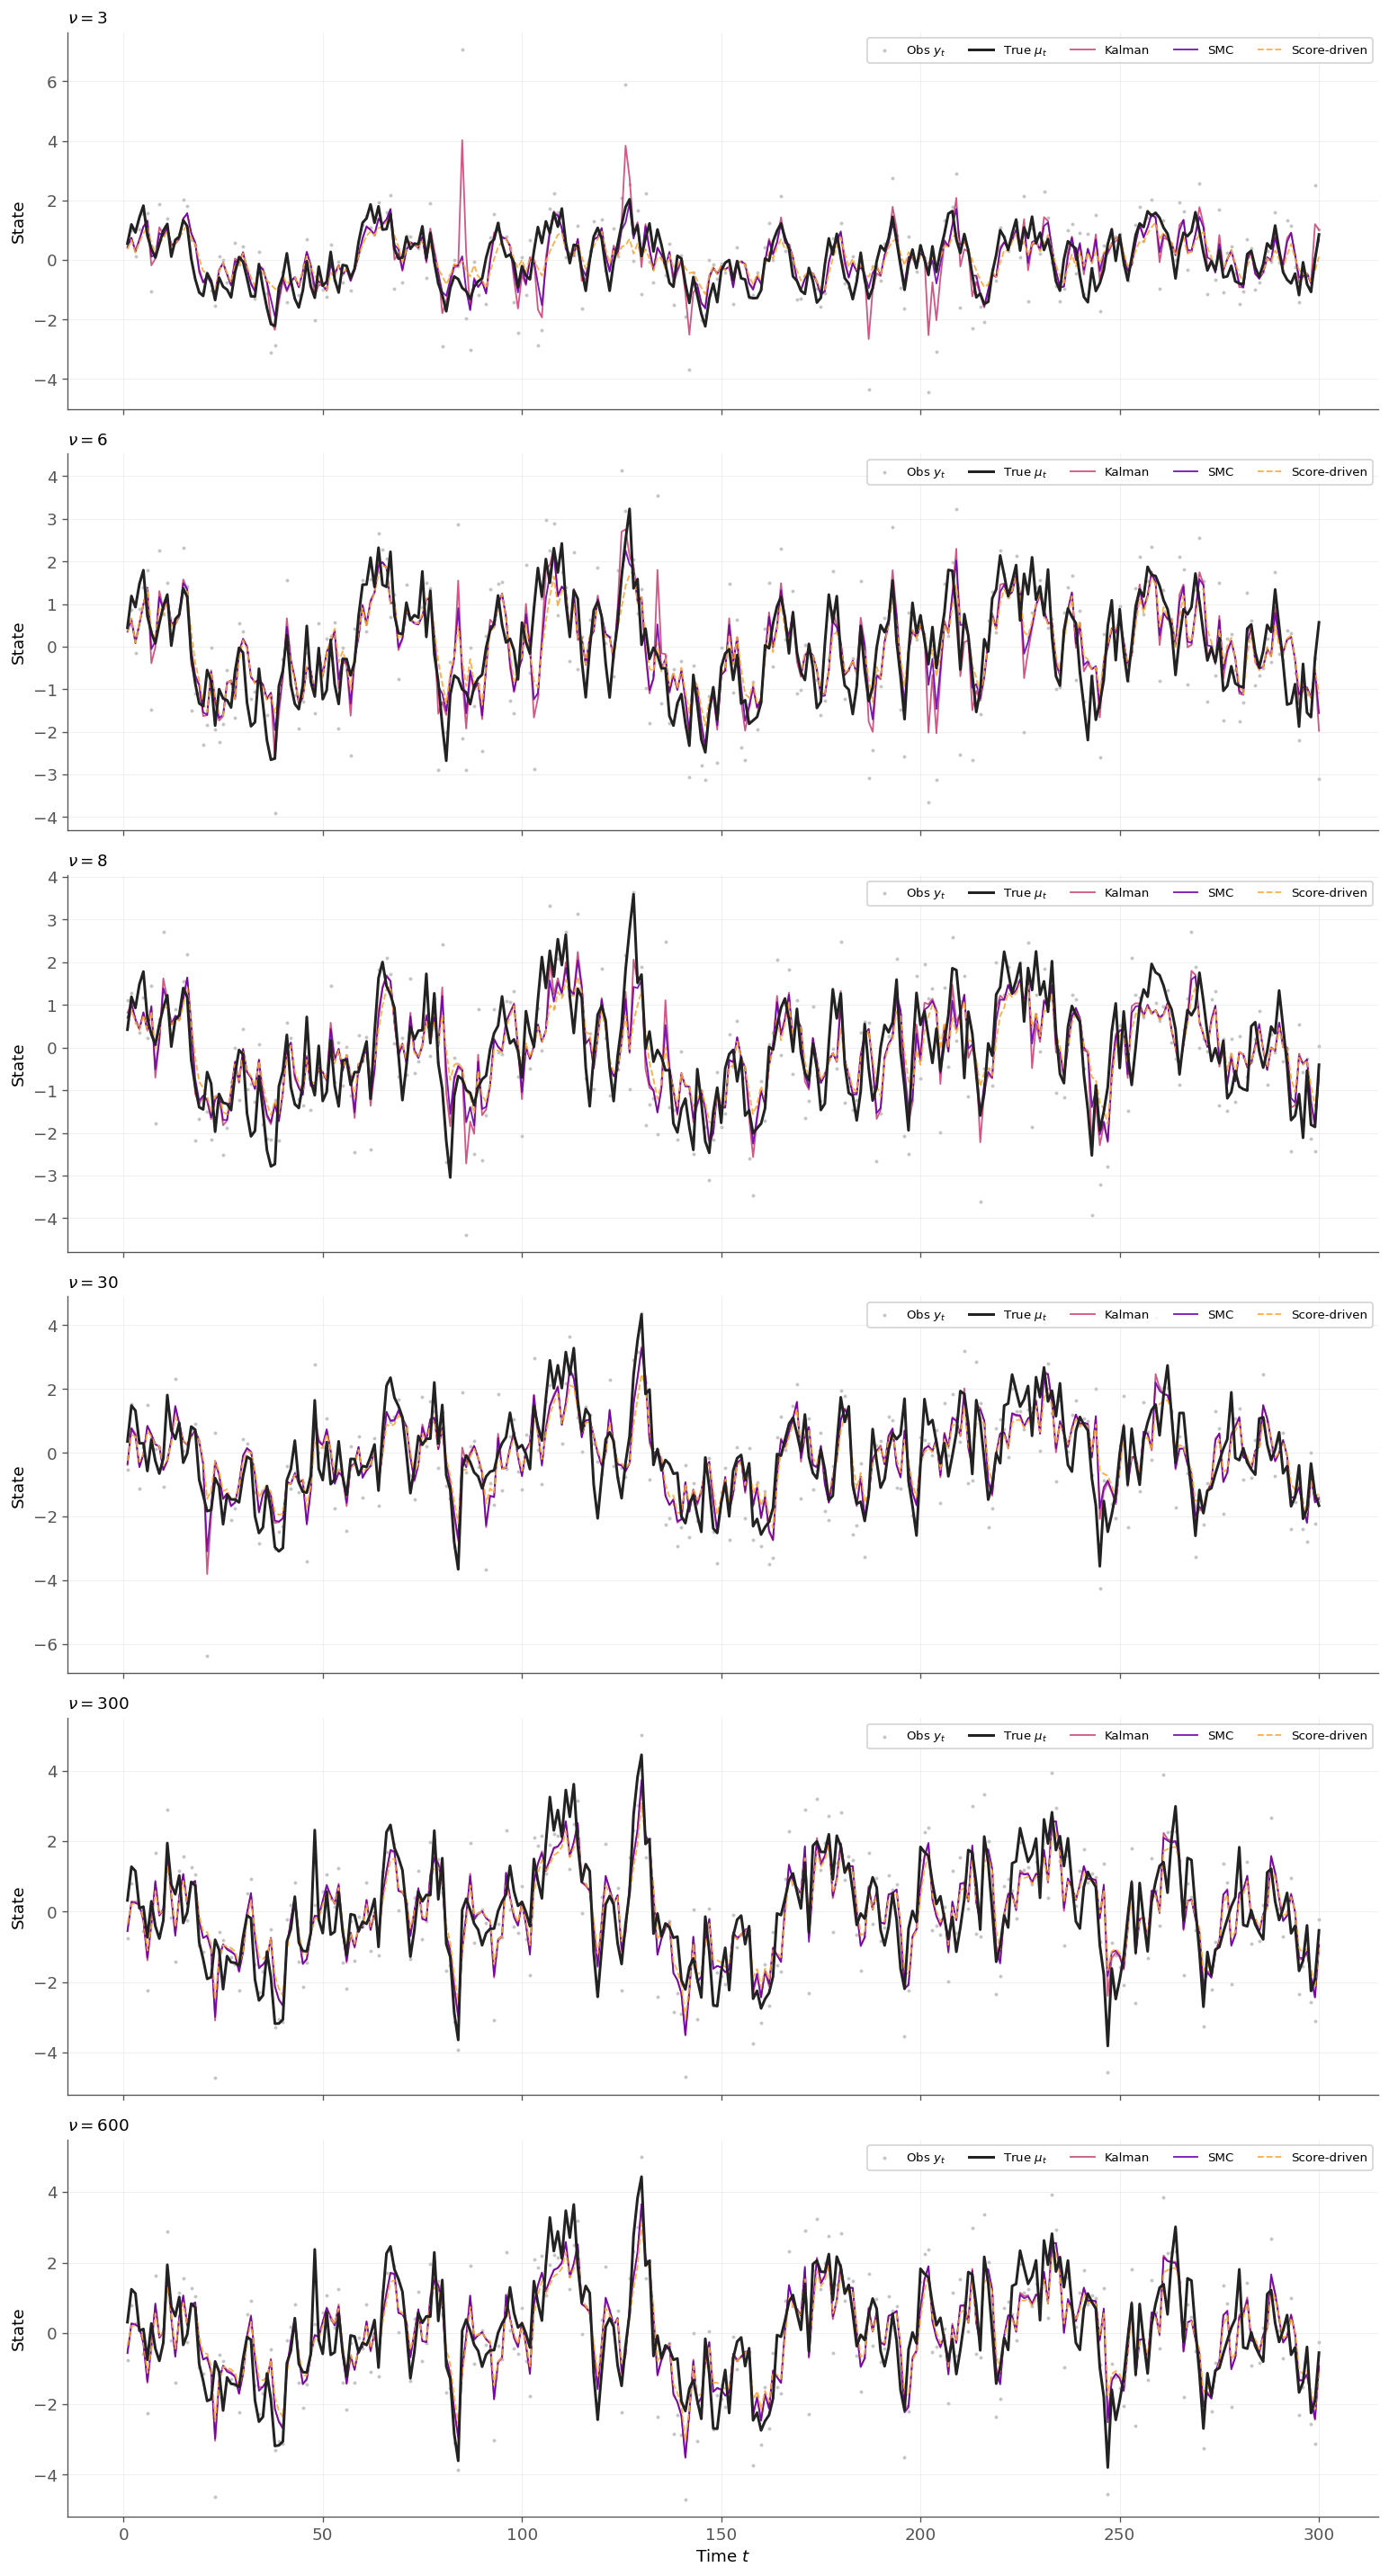

In [ ]:
# filter paths for a selection of ν values
nu_showcase = [3, 6, 8, 30, 300, 600]
fig, axes = plt.subplots(len(nu_showcase), 1, figsize=(13, 4 * len(nu_showcase)), sharex=True)

for ax, nu_val in zip(axes, nu_showcase):
    r  = sweep_results[nu_val]
    t  = np.arange(1, r['params'].T + 1)
    mu = r['mu']

    ax.scatter(t, r['y'], s=2, c='#B8B8B8', zorder=1, alpha=0.7, label=r'Obs $y_t$')
    ax.plot(t, mu[1:],        '-',  color='#222222', lw=1.8, zorder=4, label=r'True $\mu_t$')
    ax.plot(t, r['kf_mean'],  '-',  color='#CC4678', lw=1.1, alpha=0.9, label='Kalman')
    ax.plot(t, r['mu_smc'],   '-',  color='#6A00A8', lw=1.1, alpha=0.9, label='SMC')
    ax.plot(t, r['mu_sd'],    '--', color='#FCA636', lw=1.1, alpha=0.9, label='Score-driven')
    ax.set_ylabel('State')
    ax.set_title(r'$\nu=' + str(nu_val) + r'$', loc='left', fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=5)

axes[-1].set_xlabel('Time $t$')
plt.tight_layout()
plt.savefig('figs/paths_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Monte Carlo Averaged Results

independent replications each with a fresh state/observation draw


In [15]:
N_REPS = 100
nu_sweep_mc = [3, 4, 5, 6, 7,  8, 9, 10, 30, 100, 300, 600]

mc_sweep = {}
print(f'Running MC DoF sweep ({N_REPS} reps × {len(nu_sweep_mc)} ν values)...')
for nu_val in nu_sweep_mc:
    p = ss.ModelParams(nu=float(nu_val), seed=0)
    mc_sweep[nu_val] = ss.run_mc_experiment(p, n_reps=N_REPS)
    m = mc_sweep[nu_val]
    print(f'  ν={nu_val:<4}  SMC RMSE={m["metrics_smc"]["RMSE"]["mean"]:.4f}±{m["metrics_smc"]["RMSE"]["std"]:.4f}  '
          f'SD RMSE={m["metrics_sd"]["RMSE"]["mean"]:.4f}±{m["metrics_sd"]["RMSE"]["std"]:.4f}  '
          f'κ_ML={m["kappa_ml"]["mean"]:.3f}±{m["kappa_ml"]["std"]:.3f}')
print('Done.')


Running MC DoF sweep (100 reps × 12 ν values)...
  ν=3     SMC RMSE=0.5388±0.0296  SD RMSE=0.5828±0.0403  κ_ML=1.268±0.195
  ν=4     SMC RMSE=0.6064±0.0324  SD RMSE=0.6392±0.0352  κ_ML=1.017±0.172
  ν=5     SMC RMSE=0.6379±0.0327  SD RMSE=0.6658±0.0370  κ_ML=0.940±0.147
  ν=6     SMC RMSE=0.6628±0.0324  SD RMSE=0.6875±0.0360  κ_ML=0.881±0.119
  ν=7     SMC RMSE=0.6769±0.0347  SD RMSE=0.6983±0.0362  κ_ML=0.851±0.109
  ν=8     SMC RMSE=0.6904±0.0369  SD RMSE=0.7118±0.0409  κ_ML=0.832±0.109
  ν=9     SMC RMSE=0.6988±0.0357  SD RMSE=0.7183±0.0377  κ_ML=0.796±0.108
  ν=10    SMC RMSE=0.7072±0.0348  SD RMSE=0.7259±0.0378  κ_ML=0.786±0.111
  ν=30    SMC RMSE=0.7422±0.0333  SD RMSE=0.7504±0.0334  κ_ML=0.665±0.078
  ν=100   SMC RMSE=0.7540±0.0295  SD RMSE=0.7578±0.0305  κ_ML=0.616±0.071
  ν=300   SMC RMSE=0.7598±0.0305  SD RMSE=0.7635±0.0311  κ_ML=0.599±0.071
  ν=600   SMC RMSE=0.7606±0.0308  SD RMSE=0.7643±0.0312  κ_ML=0.594±0.070
Done.


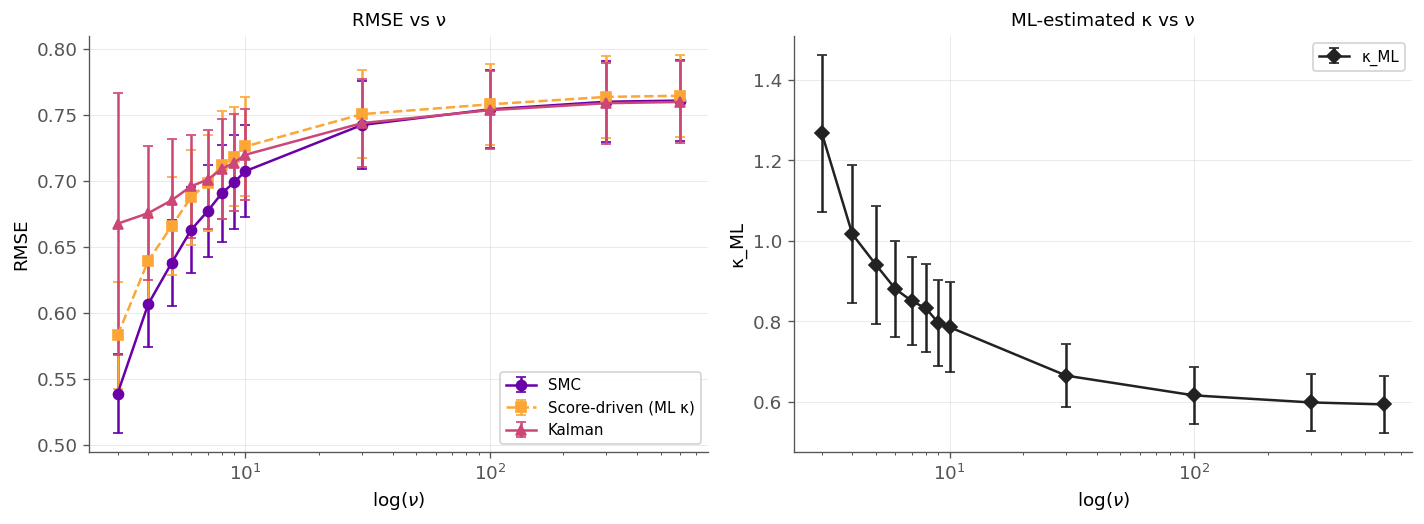

In [16]:
fig = ss.plot_dof_sweep_mc(mc_sweep)
plt.savefig('figs/dof_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
records = []
for nu_val in nu_sweep_mc:
    m = mc_sweep[nu_val]
    kf    = m['metrics_kf']
    smc   = m['metrics_smc']
    sd    = m['metrics_sd']
    kappa = m['kappa_ml']
    sigma_stat = ss.stationary_scale(ss.ModelParams(nu=float(nu_val)))
    rmse_ratio_kf = kf['RMSE']['mean']  / smc['RMSE']['mean']
    rmse_ratio_sd = sd['RMSE']['mean']  / smc['RMSE']['mean']
    records.append({
        'ν':               nu_val,
        'σ_stat':          round(sigma_stat, 4),
        'κ_ML (mean±std)': f"{kappa['mean']:.3f}±{kappa['std']:.3f}",
        'KF RMSE':         f"{kf['RMSE']['mean']:.4f}±{kf['RMSE']['std']:.4f}",
        'SMC RMSE':        f"{smc['RMSE']['mean']:.4f}±{smc['RMSE']['std']:.4f}",
        'SD RMSE':         f"{sd['RMSE']['mean']:.4f}±{sd['RMSE']['std']:.4f}",
        'KF / SMC':        round(rmse_ratio_kf, 3),
        'SD / SMC':        round(rmse_ratio_sd, 3),
    })

mc_df = pd.DataFrame(records).set_index('ν')
display(
    mc_df.style
    .set_caption(f'MC Results: Filter Performance vs Degrees of Freedom  (T=300, N=1000, reps={N_REPS})')
    .background_gradient(cmap='RdYlGn_r', subset=['KF / SMC', 'SD / SMC'])
    .set_properties(**{'text-align': 'center'})
)

,σ_stat,κ_ML (mean±std),KF RMSE,SMC RMSE,SD RMSE,KF / SMC,SD / SMC
ν,,,,,,,
3,1.020600,1.268±0.195,0.6675±0.0991,0.5388±0.0296,0.5828±0.0403,1.239000,1.082000
4,1.126900,1.017±0.172,0.6754±0.0508,0.6064±0.0324,0.6392±0.0352,1.114000,1.054000
5,1.202800,0.940±0.147,0.6852±0.0461,0.6379±0.0327,0.6658±0.0370,1.074000,1.044000
6,1.259900,0.881±0.119,0.6958±0.0390,0.6628±0.0324,0.6875±0.0360,1.050000,1.037000
7,1.304400,0.851±0.109,0.7008±0.0377,0.6769±0.0347,0.6983±0.0362,1.035000,1.032000
8,1.340100,0.832±0.109,0.7089±0.0380,0.6904±0.0369,0.7118±0.0409,1.027000,1.031000
9,1.369300,0.796±0.108,0.7138±0.0366,0.6988±0.0357,0.7183±0.0377,1.021000,1.028000
10,1.393700,0.786±0.111,0.7196±0.0346,0.7072±0.0348,0.7259±0.0378,1.018000,1.026000
30,1.563300,0.665±0.078,0.7436±0.0335,0.7422±0.0333,0.7504±0.0334,1.002000,1.011000
